<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Serena Saggion


# Introducción
En este trabajo práctico se estudian los primeros conceptos de estimación espectral mediante la Transformada Discreta de Fourier (DFT). A partir de señales senoidales contaminadas con ruido, se implementan estimadores de amplitud y frecuencia utilizando distintas funciones ventana. Además, se analiza el desempeño de dichos estimadores mediante el cálculo del sesgo y la varianza para diferentes relaciones señal-ruido (SNR), con el objetivo de evaluar la influencia del ruido y de la ventana seleccionada sobre la precisión de las estimaciones.


# Teoría

## Relación señal-ruido (SNR)

La relación señal-ruido (SNR) es una medida que cuantifica la potencia de una señal respecto de la potencia del ruido que la contamina. Se expresa habitualmente en decibeles (dB) mediante
\begin{equation}SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right)\end{equation}

donde **Ps**es la potencia de la señal y **Pn** la potencia del ruido. Un mayor valor de SNR indica que la señal predomina sobre el ruido, permitiendo obtener estimaciones más precisas de sus parámetros.

## Ruido

En este trabajo se considera un ruido blanco gaussiano aditivo, modelado como una variable aleatoria con distribución normal de media cero y varianza (\sigma^2):
\begin{equation}n_a \sim \mathcal{N}(0,\sigma^2)\end{equation}

Este tipo de ruido representa una perturbación aleatoria que afecta las muestras de la señal y dificulta la estimación de su amplitud y frecuencia.

## Funciones ventana

Al analizar una señal mediante la Transformada Discreta de Fourier (DFT), únicamente se dispone de un número finito de muestras. La aplicación de una función ventana permite reducir los efectos del desparramo espectral, modificando la forma del espectro obtenido. En este trabajo se utilizan las ventanas rectangular, Flat-top, Blackman-Harris y Hann, cada una con un compromiso diferente entre resolución espectral y atenuación de los lóbulos laterales.

## Estimadores

Un estimador es una regla o procedimiento que permite obtener una aproximación de un parámetro desconocido a partir de un conjunto de datos observados. En este trabajo se emplean dos estimadores espectrales: uno para la amplitud de la senoidal, obtenido a partir del módulo del espectro en una frecuencia determinada, y otro para la frecuencia, definido como la ubicación del máximo del módulo de la DFT.

## Sesgo

El sesgo mide la diferencia entre el valor medio estimado y el valor verdadero del parámetro. Para la amplitud se define como
\begin{equation}s_a = E{\hat a}-a_0\end{equation}

mientras que para la frecuencia
\begin{equation}s_\Omega = E{\hat\Omega}-\Omega_1\end{equation}


Un estimador con sesgo cercano a cero se considera poco sesgado, ya que sus estimaciones, en promedio, coinciden con el valor real.

## Varianza

La varianza mide la dispersión de las estimaciones alrededor de su valor medio. Un estimador con baja varianza produce resultados más consistentes al repetir el experimento. En este trabajo, la varianza se calcula experimentalmente a partir de las distintas realizaciones generadas para cada combinación de ventana y relación señal-ruido.


# Procedimiento
Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada: rectangular, flattop y blackmanharris y hann. 


SNR = 3 dB
sigma = 0.7079457843841379

------------------------------------
Ventana: Rectangular
------------------------------------
Estimación de amplitud
Media: 0.5522834899248973
Sesgo: -0.8619300724481979
Varianza: 0.23966460875298787

Estimación de frecuencia
Sesgo: 2.3358938140297657e-05
Varianza: 3.2925246987209036e-06

------------------------------------
Ventana: Flat-top
------------------------------------
Estimación de amplitud
Media: 0.23431477098164785
Sesgo: -1.1798987913914474
Varianza: 0.006654024558734566

Estimación de frecuencia
Sesgo: -5.60722179459483e-05
Varianza: 7.200190691963647e-06

------------------------------------
Ventana: Blackman-Harris
------------------------------------
Estimación de amplitud
Media: 0.26810131084194216
Sesgo: -1.146112251531153
Varianza: 0.03184936500360751

Estimación de frecuencia
Sesgo: 6.998616556479042e-05
Varianza: 3.4188821375637287e-06

------------------------------------
Ventana: Hann
------------------------------------

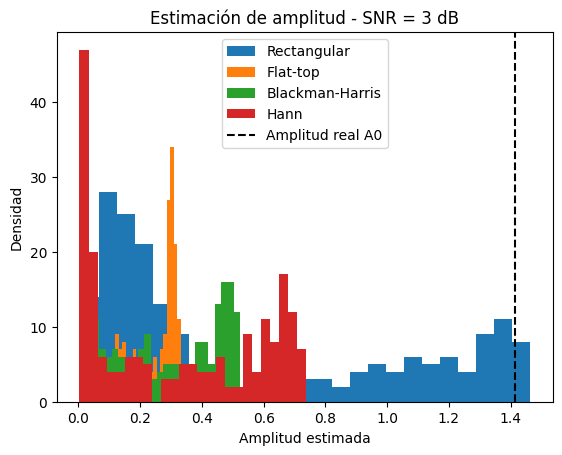

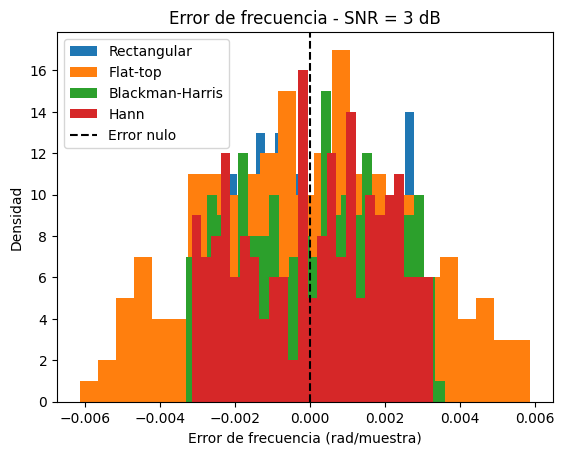


SNR = 10 dB
sigma = 0.31622776601683794

------------------------------------
Ventana: Rectangular
------------------------------------
Estimación de amplitud
Media: 0.5226403242202073
Sesgo: -0.8915732381528878
Varianza: 0.22606087156465715

Estimación de frecuencia
Sesgo: -0.00021465283771129106
Varianza: 3.6625010997808453e-06

------------------------------------
Ventana: Flat-top
------------------------------------
Estimación de amplitud
Media: 0.23544579069914218
Sesgo: -1.1787677716739529
Varianza: 0.0074259669637931555

Estimación de frecuencia
Sesgo: 1.5837410286634324e-06
Varianza: 5.04702368465601e-06

------------------------------------
Ventana: Blackman-Harris
------------------------------------
Estimación de amplitud
Media: 0.28744162189259276
Sesgo: -1.1267719404805023
Varianza: 0.031203573639612122

Estimación de frecuencia
Sesgo: 0.0001138661519561357
Varianza: 3.3015051542476995e-06

------------------------------------
Ventana: Hann
------------------------------

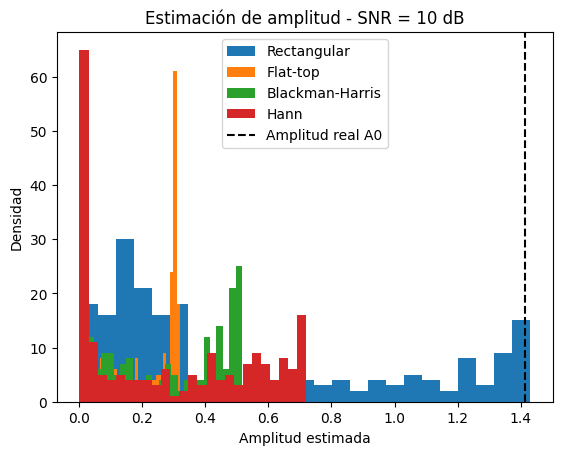

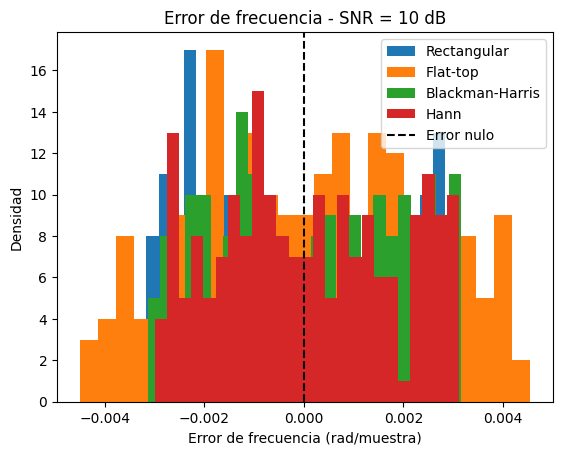

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

def mi_sen_omega(vmax, dc, Omega, ph, nn):
    n = np.arange(nn)
    xx = dc + vmax*np.sin(Omega*n + ph)
    return n, xx

# Parámetros
N = 1000
M = 200

Omega0 = np.pi/2
a0 = np.sqrt(2)   # potencia senoidal = 1 W

SNRs = [3, 10]

ventanas = {
    "Rectangular": np.ones(N),
    "Flat-top": windows.flattop(N),
    "Blackman-Harris": windows.blackmanharris(N),
    "Hann": windows.hann(N)
}

Omega = 2*np.pi*np.arange(N)/N
k0 = int(Omega0/(2*np.pi/N))

for SNR in SNRs:

    resultados_a = {}
    resultados_Omega = {}

    Ps = 1
    Pn = Ps/(10**(SNR/10))
    sigma = np.sqrt(Pn)

    print("\n====================================")
    print("SNR =", SNR, "dB")
    print("sigma =", sigma)
    print("====================================")

    for nombre, w in ventanas.items():

        # Matriz: M señales de N muestras
        X = np.zeros((M, N))

        a_est = np.zeros(M)
        Omega_est = np.zeros(M)
        Omega_real = np.zeros(M)

        # Generación de realizaciones
        for j in range(M):

            fr = np.random.uniform(-2, 2)
            Omega1 = Omega0 + fr*(2*np.pi/N)

            Omega_real[j] = Omega1

            n, x = mi_sen_omega(
                vmax=a0,
                dc=0,
                Omega=Omega1,
                ph=0,
                nn=N
            )

            ruido = np.random.normal(0, sigma, N)

            X[j, :] = x + ruido


        # Estimación para cada fila
        for j in range(M):

            xw = X[j, :] * w

            Xw = np.fft.fft(xw)

            # Estimador de amplitud
            a_est[j] = (2/N) * np.abs(Xw[k0])

            # Estimador de frecuencia
            kmax = np.argmax(np.abs(Xw[:N//2]))
            Omega_est[j] = Omega[kmax]


        # Sesgo y varianza amplitud
        mu_a = np.mean(a_est)
        sesgo_a = mu_a - a0
        var_a = np.var(a_est)

        # Sesgo y varianza frecuencia
        error_Omega = Omega_est - Omega_real

        sesgo_Omega = np.mean(error_Omega)
        var_Omega = np.var(error_Omega)

        #resultados para histogramas
        resultados_a[nombre] = a_est.copy()
        resultados_Omega[nombre] = error_Omega.copy()

        print("\n------------------------------------")
        print("Ventana:", nombre)
        print("------------------------------------")

        print("Estimación de amplitud")
        print("Media:", mu_a)
        print("Sesgo:", sesgo_a)
        print("Varianza:", var_a)

        print("\nEstimación de frecuencia")
        print("Sesgo:", sesgo_Omega)
        print("Varianza:", var_Omega)

    # Histograma de amplitud
    plt.figure()

    for nombre, valores in resultados_a.items():
        plt.hist(valores, bins=25, label=nombre)

    plt.axvline(a0, color="black", linestyle="--",
                label="Amplitud real A0")

    plt.title(f"Estimación de amplitud - SNR = {SNR} dB")
    plt.xlabel("Amplitud estimada")
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()


    # Histograma de error de frecuencia
    plt.figure()

    for nombre, valores in resultados_Omega.items():
        plt.hist(valores, bins=25, label=nombre)

    plt.axvline(0, color="black", linestyle="--",
                label="Error nulo")

    plt.title(f"Error de frecuencia - SNR = {SNR} dB")
    plt.xlabel("Error de frecuencia (rad/muestra)")
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()

# Analisis de Resultados

En la estimación de amplitud se observó que todas las ventanas presentaron un sesgo negativo, indicando que el estimador tendió a subestimar la amplitud real de la señal. Al incrementar la SNR de 3 dB a 10 dB, la varianza disminuyó levemente en las ventanas analizadas, lo que indica una menor dispersión de las estimaciones debido a la reducción del ruido. Entre las ventanas estudiadas, la rectangular presentó el menor sesgo, mientras que la Flat-top presentó la menor varianza. Las ventanas Blackman-Harris y Hann mostraron comportamientos diferentes debido al efecto que introduce cada ventana sobre el espectro.

Es importante destacar que el aumento de la SNR no elimina completamente el error en la estimación de amplitud. Esto se debe a que, además del ruido, la estimación está influenciada por la ventana utilizada y por el desplazamiento de la frecuencia de la señal respecto de los bins de la DFT.

Respecto de la estimación de frecuencia, los sesgos obtenidos fueron muy pequeños, indicando que las frecuencias estimadas se encontraron, en promedio, cercanas a las frecuencias reales. Asimismo, las varianzas fueron bajas y disminuyeron ligeramente para una SNR de 10 dB, reflejando una menor dispersión de los errores cuando el nivel de ruido fue menor. En general, las diferencias entre las ventanas fueron reducidas para este estimador.

En los histogramas de error de frecuencia se observa que, para una SNR de 10 dB, los errores tienden a concentrarse más cerca de cero que para una SNR de 3 dB. Esto ocurre porque, al aumentar la SNR, disminuye la potencia del ruido Pn, por lo que la señal se encuentra menos afectada por el ruido.

En conjunto, los resultados muestran que una mayor SNR reduce la influencia del ruido y tiende a disminuir la dispersión de las estimaciones. La elección de la ventana tiene una influencia importante en la estimación de amplitud, mientras que para la estimación de frecuencia se obtuvieron sesgos pequeños y varianzas reducidas con las cuatro ventanas analizadas.


# Conclusión

En este trabajo práctico se analizaron estimadores espectrales de amplitud y frecuencia obtenidos a partir de la Transformada Discreta de Fourier (DFT), evaluando el efecto de distintas funciones ventana y de diferentes niveles de relación señal-ruido (SNR).

A partir de las simulaciones se observó que, al aumentar la SNR, disminuye la potencia del ruido y, en general, se reduce la dispersión de las estimaciones. Este efecto se evidenció especialmente en la estimación de frecuencia, donde los errores tendieron a concentrarse más cerca de cero para una SNR de 10 dB y se obtuvieron sesgos muy pequeños y varianzas reducidas para las distintas ventanas analizadas.

En la estimación de amplitud, en cambio, se observaron diferencias más marcadas entre las ventanas. Todas presentaron sesgo negativo, lo que indica una tendencia a subestimar la amplitud real. Si bien al aumentar la SNR la varianza tendió a disminuir, el error de amplitud no depende únicamente del ruido, sino también de la ventana utilizada y del desplazamiento de la frecuencia de la señal respecto de los bins de la DFT.

Por lo tanto, los resultados muestran que una mayor SNR mejora principalmente la estabilidad de las estimaciones al reducir la influencia del ruido, pero la precisión final también depende del estimador utilizado y de la ventana seleccionada. En particular, la elección de la ventana resultó más determinante en la estimación de amplitud, mientras que la estimación de frecuencia presentó un comportamiento más estable entre las distintas ventanas.
